In [ ]:
import pandas as pd

### SHEET 1

## STEP 1: Lihat anomali di sheet


In [ ]:
# Baca sheet
df = pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name="Transaksi_BI")

In [ ]:
print(df.head(10).to_string())

      Tanggal Kode_Transaksi           Kantor_BI Kanal_Pembayaran Jenis_Transaksi     Kategori Nilai_Transaksi  Biaya_Admin
0  2024-03-01      TRX000001   KPwBI DKI Jakarta             QRIS      Pemerintah   Penerimaan      -582831000       2500.0
1  2024-10-20      TRX000002          KPwBI Bali            Tunai        Individu  Pengeluaran     657.755.000          0.0
2  2024-01-02      TRX000003   KPwBI DKI Jakarta      Kartu Debit        Individu  Pengeluaran             NaN       2500.0
3  2024-12-16      TRX000004          KPwBI Bali            Tunai       Korporasi   Penerimaan      -283496000          0.0
4  01/07/2024      TRX000005  KPwBI DKI Jakarta      Kartu Kredit       Korporasi   Penerimaan       651078000       5000.0
5  2024-08-22      TRX000006   KPwBI Jawa Timur              QRIS       Korporasi  Pengeluaran       633874000       2500.0
6  29/12/2024      TRX000007   KPwBI DKI Jakarta            tunai        Individu   Penerimaan       415504000          0.0
7  29/02

In [ ]:
# Lihat tipe data setiap kolom
print(df.dtypes)

Tanggal              object
Kode_Transaksi       object
Kantor_BI            object
Kanal_Pembayaran     object
Jenis_Transaksi      object
Kategori             object
Nilai_Transaksi      object
Biaya_Admin         float64
dtype: object


In [ ]:
# Lihat missing value setiap kolom
print(df.isna().sum())

Tanggal             0
Kode_Transaksi      0
Kantor_BI           4
Kanal_Pembayaran    4
Jenis_Transaksi     3
Kategori            2
Nilai_Transaksi     5
Biaya_Admin         6
dtype: int64


In [ ]:
df.columns.to_list()

['Tanggal',
 'Kode_Transaksi',
 'Kantor_BI',
 'Kanal_Pembayaran',
 'Jenis_Transaksi',
 'Kategori',
 'Nilai_Transaksi',
 'Biaya_Admin']

In [ ]:
# Lihat unique value setiap kolom
for nama_kolom in ['Tanggal', 'Kode_Transaksi', 'Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori', 'Nilai_Transaksi', 'Biaya_Admin']:
  print(nama_kolom, "->", list(df[nama_kolom].unique()))
  print()

Tanggal -> ['2024-03-01', '2024-10-20', '2024-01-02', '2024-12-16', '01/07/2024', '2024-08-22', '29/12/2024', '29/02/2024', '2024-09-25', '2024-03-07', '03/09/2024', '2024-12-31', '2024-12-08', '09/08/2024', '03/07/2024', '2024-08-10', '20/02/2024', '2024-04-03', '2024-09-12', '08/01/2024', datetime.datetime(2024, 3, 2, 0, 0), '2024-01-03', '30 August 2024', '27/10/2024', '2024-11-26', datetime.datetime(2024, 6, 16, 0, 0), '19/10/2024', datetime.datetime(2024, 11, 15, 0, 0), '2024-01-18', datetime.datetime(2024, 11, 24, 0, 0), '21/09/2024', '2024-05-19', datetime.datetime(2024, 4, 5, 0, 0), '27 August 2024', '2024-04-19', '2024-10-06', '14 October 2024', datetime.datetime(2024, 10, 18, 0, 0), '19/02/2024', '2024-04-04', '2024-06-10', datetime.datetime(2024, 1, 8, 0, 0), '10 June 2024', '2024-08-06', '2024-07-18', '2024-05-24', datetime.datetime(2024, 6, 12, 0, 0), '27/02/2024', '15 January 2024', datetime.datetime(2024, 5, 2, 0, 0), '2024-05-10', '2024-05-15', '10 October 2024', '02/12

In [ ]:
df.describe()

,Biaya_Admin
count,194.000000
mean,1595.360825
std,1777.064332
min,-2500.000000
25%,0.000000
50%,2500.000000
75%,2500.000000
max,7500.000000


## MOVE TO GEMINI

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

# Simpan jumlah baris awal untuk pengecekan nanti
n_awal = len(df)

# Urutan format tanggal yang akan dicoba
formats = ['%Y-%m-%d', '%d/%m/%Y', '%d %B %Y']
hasil_tanggal = []
gagal_baca = 0

# Membaca baris satu per satu dengan for-loop
for val in df['Tanggal']:
    if pd.isna(val) or val is None:
        hasil_tanggal.append(pd.NaT)
        gagal_baca += 1
        continue

    # Jika sudah bertipe datetime/Timestamp, biarkan
    if isinstance(val, (pd.Timestamp, datetime)):
        hasil_tanggal.append(val)
        continue

    # Parsing string tanggal
    val_str = str(val).strip()
    parsed = None
    for fmt in formats:
        try:
            parsed = pd.Timestamp(datetime.strptime(val_str, fmt))
            break
        except ValueError:
            pass

    if parsed is not None:
        hasil_tanggal.append(parsed)
    else:
        hasil_tanggal.append(pd.NaT)
        gagal_baca += 1

# Simpan kembali sebagai tipe data tanggal asli
df['Tanggal'] = hasil_tanggal
print(f"Jumlah tanggal yang gagal dibaca: {gagal_baca}")

Jumlah tanggal yang gagal dibaca: 0


In [ ]:
# Kolom teks yang akan dibersihkan
kolom_teks = ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']

for col in kolom_teks:
    # 1. Pastikan nilai null/NaN asli tidak berubah menjadi teks 'nan'
    # Buang spasi depan & belakang hanya pada data string
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

    # Ubah teks 'nan', 'None', atau string kosong "" menjadi NaN asli
    df[col] = df[col].replace(['nan', 'NaN', 'None', 'null', ''], np.nan)

    # 2. Cari penulisan yang paling sering muncul (modus) untuk tiap variasi huruf
    valid_mask = df[col].notnull()
    if valid_mask.any():
        mode_map = {}
        for lower_val, group in df[col][valid_mask].groupby(df[col][valid_mask].str.lower()):
            mode_val = group.mode()[0]
            mode_map[lower_val] = mode_val

        # Samakan penulisan berdasarkan versi tersering
        df.loc[valid_mask, col] = df.loc[valid_mask, col].str.lower().map(mode_map)

In [ ]:
kolom_angka = ['Nilai_Transaksi', 'Biaya_Admin']

for col in kolom_angka:
    hasil_angka = []
    for val in df[col]:
        if pd.isna(val) or val is None or str(val).strip().lower() in ['nan', 'none', '']:
            hasil_angka.append(np.nan)
        # Jika sudah berupa angka, biarkan (jangan hapus titik float)
        elif isinstance(val, (int, float, np.number)):
            hasil_angka.append(float(val))
        # Jika berupa teks, bersihkan 'Rp', spasi, titik (.), dan koma (,) pemisah ribuan
        elif isinstance(val, str):
            val_clean = val.replace('Rp', '').replace(' ', '').strip()
            val_clean = val_clean.replace('.', '').replace(',', '')
            try:
                hasil_angka.append(float(val_clean))
            except ValueError:
                hasil_angka.append(np.nan)
        else:
            hasil_angka.append(np.nan)

    df[col] = hasil_angka

In [ ]:
# 1. Hapus baris duplikat persis
df = df.drop_duplicates().reset_index(drop=True)

# 2. Nilai negatif & nilai ekstrem (metode IQR 3x) diubah menjadi NaN
for col in ['Nilai_Transaksi', 'Biaya_Admin']:
    df.loc[df[col] < 0, col] = np.nan

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr

    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan

# 3. Isi sel kosong (imputasi)
# Median untuk angka
for col in ['Nilai_Transaksi', 'Biaya_Admin']:
    df[col] = df[col].fillna(df[col].median())

# Modus untuk teks & kategori (mengabaikan NaN saat cari modus)
for col in ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']:
    # Ubah sekali lagi jika masih ada string 'nan' tersisa
    df[col] = df[col].replace('nan', np.nan)
    if df[col].isnull().sum() > 0:
        modus_val = df[col].dropna().mode()[0]
        df[col] = df[col].fillna(modus_val)

if df['Tanggal'].isnull().sum() > 0:
    modus_tgl = df['Tanggal'].dropna().mode()[0]
    df['Tanggal'] = df['Tanggal'].fillna(modus_tgl)

In [ ]:
print("=== HASIL PENGECEKAN DATA BERSINH ===")
print(f"Jumlah baris awal  : {n_awal}")
print(f"Jumlah baris akhir : {len(df)}")
print(f"Jumlah sel kosong tersisa: {df.isnull().sum().sum()}")
print("-" * 40)

print("NILAI MINIMUM & MAKSIMUM (KOLOM ANGKA):")
for col in ['Nilai_Transaksi', 'Biaya_Admin']:
    min_val = df[col].min()
    max_val = df[col].max()
    # Menampilkan angka murni tanpa koma pemisah ribuan
    print(f"- {col}: Min = {min_val:.2f} | Max = {max_val:.2f}")

print("-" * 40)
print("RENTANG TANGGAL:")
print(f"- Paling awal : {df['Tanggal'].min().strftime('%Y-%m-%d')}")
print(f"- Paling akhir: {df['Tanggal'].max().strftime('%Y-%m-%d')}")

print("-" * 40)
print("NILAI UNIK KOLOM KATEGORI / TEKS:")
for col in ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']:
    print(f"- {col}: {list(df[col].unique())}")

=== HASIL PENGECEKAN DATA BERSINH ===
Jumlah baris awal  : 200
Jumlah baris akhir : 194
Jumlah sel kosong tersisa: 0
----------------------------------------
NILAI MINIMUM & MAKSIMUM (KOLOM ANGKA):
- Nilai_Transaksi: Min = 9340000.00 | Max = 893436000.00
- Biaya_Admin: Min = 0.00 | Max = 7500.00
----------------------------------------
RENTANG TANGGAL:
- Paling awal : 2024-01-01
- Paling akhir: 2024-12-31
----------------------------------------
NILAI UNIK KOLOM KATEGORI / TEKS:
- Kantor_BI: ['KPwBI DKI Jakarta', 'KPwBI Bali', 'KPwBI Jawa Timur', 'BI Pusat', 'KPwBI Jawa Barat', 'KPwBI Sumatera Utara']
- Kanal_Pembayaran: ['QRIS', 'Tunai', 'Kartu Debit', 'Kartu Kredit', 'Transfer BI-FAST']
- Jenis_Transaksi: ['Pemerintah', 'Individu', 'Korporasi', 'UMKM']
- Kategori: ['Penerimaan', 'Pengeluaran']


In [ ]:
print(df.dtypes)

Tanggal             datetime64[ns]
Kode_Transaksi              object
Kantor_BI                   object
Kanal_Pembayaran            object
Jenis_Transaksi             object
Kategori                    object
Nilai_Transaksi            float64
Biaya_Admin                float64
dtype: object


## Simpan hasil pembersihan ke dalam variable ba

In [ ]:
df_transaksi = df.copy()

## SHEET 2

## Kenalan dengan dataset dan temukan anomalinya

In [ ]:
df=pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name="Survei_Persepsi")

In [ ]:
print(df.head(10).to_string())

  ID_Responden usia Jenis Kelamin         Domisili          Pekerjaan  Frekuensi_Gunakan_QRIS    Kepuasan_Layanan_QRIS  persepsi_keamanan_transaksi  Pengetahuan BI FAST  Niat_Menggunakan_Lagi  loyalitas
0        R0001   46     Laki-laki        Jawa Barat     PNS/TNI/Polri                        7                     5.0                            4                    4                      1        3.0
1        R0002   49     Laki-laki       Jawa Tengah     PNS/TNI/Polri                        5                     5.0                            1                    2                      2        4.0
2        R0003   21     Laki-laki  Sulawesi Selatan   Pegawai Swasta                         7                     1.0                            5                    4                      1        3.0
3        R0004   53     Laki-laki       Jawa Tengah  Ibu Rumah Tangga                        7                     5.0                            5                    1                    

In [ ]:
print(df.dtypes)

ID_Responden                    object
usia                            object
Jenis Kelamin                   object
Domisili                        object
Pekerjaan                       object
Frekuensi_Gunakan_QRIS           int64
 Kepuasan_Layanan_QRIS         float64
persepsi_keamanan_transaksi      int64
Pengetahuan BI FAST              int64
Niat_Menggunakan_Lagi            int64
loyalitas                      float64
dtype: object


In [ ]:
print(df.isna().sum())

ID_Responden                   0
usia                           5
Jenis Kelamin                  0
Domisili                       3
Pekerjaan                      4
Frekuensi_Gunakan_QRIS         0
 Kepuasan_Layanan_QRIS         6
persepsi_keamanan_transaksi    0
Pengetahuan BI FAST            0
Niat_Menggunakan_Lagi          0
loyalitas                      5
dtype: int64


In [ ]:
for nama_kolom in df.columns:
  if nama_kolom == "ID_Responden" :
    continue
  print(nama_kolom)
  print(df[nama_kolom].unique().tolist())
  print()

usia
[46, 49, 21, 53, 19, 43, 55, 61, 250, 36, 20, 18, 32, 51, -5, 58, 59, nan, 26, 47, 42, 22, 34, 48, 28, 35, 31, 23, 60, 54, 44, 29, 57, 45, 41, 39, 999, 24, 40, 52, '62 tahun', 38, 62, 30, '51 tahun', 56, 25, 7, 50, 37, '46 tahun']

Jenis Kelamin
['Laki-laki', 'Perempuan', 'P', 'Perempuan ', 'L', 'laki-laki']

Domisili 
['Jawa Barat', 'Jawa Tengah', 'Sulawesi Selatan', 'Jabar', 'Bali', 'Jawa Timur', 'Sumatera Utara', 'DKI Jakarta', 'Banten', nan, 'Jakarta', 'jawa barat', 'jakarta ']

Pekerjaan
['PNS/TNI/Polri', 'Pegawai Swasta ', 'Ibu Rumah Tangga', 'Pegawai Swasta', 'Wirausaha', 'Lainnya', 'wirausaha', 'Pelajar/Mahasiswa', nan, 'PNS']

Frekuensi_Gunakan_QRIS 
[7, 5, 3, 4, 2, 1, 6, 11]

 Kepuasan_Layanan_QRIS
[5.0, 1.0, 3.0, nan, 4.0, 2.0, 9.0]

persepsi_keamanan_transaksi
[4, 1, 5, 2, 3, 9]

Pengetahuan BI FAST
[4, 2, 1, 3, 5, 0]

Niat_Menggunakan_Lagi
[1, 2, 3, 5, 4, 9]

loyalitas
[3.0, 4.0, 2.0, 1.0, 5.0, nan]



## Gemini

In [ ]:
import pandas as pd
import numpy as np

# Simpan jumlah baris awal
n_awal = len(df)

# Daftar nama kolom baru yang baku
nama_kolom_baru = [
    'ID_Responden',
    'Usia',
    'Jenis_Kelamin',
    'Domisili',
    'Pekerjaan',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]

# Hitung jumlah kolom yang nama/spasinya berubah
kolom_diubah = 0
for i in range(len(df.columns)):
    if df.columns[i] != nama_kolom_baru[i]:
        kolom_diubah += 1

# Ganti nama kolom secara langsung berdasarkan urutan
df.columns = nama_kolom_baru

print(f"Nama kolom berhasil diperbarui. Jumlah nama kolom yang disesuaikan: {kolom_diubah}")

Nama kolom berhasil diperbarui. Jumlah nama kolom yang disesuaikan: 8


In [ ]:
# Hitung jumlah baris sebelum penghapusan duplikat
baris_sebelum = len(df)

# Hapus baris duplikat persis dan reset index
df = df.drop_duplicates().reset_index(drop=True)

# Hitung jumlah duplikat yang terhapus
duplikat_terhapus = baris_sebelum - len(df)

print(f"Baris duplikat persis dihapus: {duplikat_terhapus}")

Baris duplikat persis dihapus: 4


In [ ]:
usia_baru = []
teks_tahun_dibuang = 0
usia_tidak_wajar = 0

for val in df['Usia']:
    if pd.isna(val) or val is None or str(val).strip().lower() in ['nan', 'none', '']:
        usia_baru.append(np.nan)
        continue

    val_str = str(val).strip().lower()

    # Buang tulisan 'tahun' jika ada
    if 'tahun' in val_str:
        val_str = val_str.replace('tahun', '').strip()
        teks_tahun_dibuang += 1

    try:
        angka_usia = float(val_str)
        # Usia di bawah 17 atau di atas 100 dijadikan kosong
        if angka_usia < 17 or angka_usia > 100:
            usia_baru.append(np.nan)
            usia_tidak_wajar += 1
        else:
            usia_baru.append(angka_usia)
    except ValueError:
        usia_baru.append(np.nan)
        usia_tidak_wajar += 1

df['Usia'] = usia_baru

print(f"Tulisan 'tahun' dibuang: {teks_tahun_dibuang}")
print(f"Usia tidak wajar dijadikan kosong: {usia_tidak_wajar}")

Tulisan 'tahun' dibuang: 3
Usia tidak wajar dijadikan kosong: 4


In [ ]:
# 1. Normalisasi Jenis_Kelamin
jk_baru = []
jk_diubah = 0

for val in df['Jenis_Kelamin']:
    if pd.isna(val) or str(val).strip().lower() in ['nan', 'none', '']:
        jk_baru.append(np.nan)
        continue

    teks = str(val).strip().lower()

    if teks == 'l' or teks == 'laki-laki' or teks == 'laki laki':
        hasil = 'Laki-laki'
    elif teks == 'p' or teks == 'perempuan':
        hasil = 'Perempuan'
    else:
        hasil = np.nan

    if val != hasil:
        jk_diubah += 1
    jk_baru.append(hasil)

df['Jenis_Kelamin'] = jk_baru

# 2. Normalisasi Domisili
domisili_baru = []
domisili_diubah = 0

for val in df['Domisili']:
    if pd.isna(val) or str(val).strip().lower() in ['nan', 'none', '']:
        domisili_baru.append(np.nan)
        continue

    teks = str(val).strip().lower()

    if teks == 'jakarta' or teks == 'dki jakarta':
        hasil = 'DKI Jakarta'
    elif teks == 'jabar' or teks == 'jawa barat':
        hasil = 'Jawa Barat'
    elif teks == 'jawa tengah':
        hasil = 'Jawa Tengah'
    elif teks == 'jawa timur':
        hasil = 'Jawa Timur'
    elif teks == 'banten':
        hasil = 'Banten'
    elif teks == 'bali':
        hasil = 'Bali'
    elif teks == 'sumatera utara':
        hasil = 'Sumatera Utara'
    elif teks == 'sulawesi selatan':
        hasil = 'Sulawesi Selatan'
    else:
        hasil = np.nan

    if val != hasil:
        domisili_diubah += 1
    domisili_baru.append(hasil)

df['Domisili'] = domisili_baru

# 3. Normalisasi Pekerjaan
pekerjaan_baru = []
pekerjaan_diubah = 0

for val in df['Pekerjaan']:
    if pd.isna(val) or str(val).strip().lower() in ['nan', 'none', '']:
        pekerjaan_baru.append(np.nan)
        continue

    teks = str(val).strip().lower()

    if teks == 'pns' or teks == 'pns/tni/polri':
        hasil = 'PNS/TNI/Polri'
    elif teks == 'pegawai swasta':
        hasil = 'Pegawai Swasta'
    elif teks == 'wirausaha':
        hasil = 'Wirausaha'
    elif teks == 'ibu rumah tangga':
        hasil = 'Ibu Rumah Tangga'
    elif teks == 'pelajar/mahasiswa':
        hasil = 'Pelajar/Mahasiswa'
    elif teks == 'lainnya':
        hasil = 'Lainnya'
    else:
        hasil = np.nan

    if val != hasil:
        pekerjaan_diubah += 1
    pekerjaan_baru.append(hasil)

df['Pekerjaan'] = pekerjaan_baru

print(f"Nilai Jenis_Kelamin disamakan: {jk_diubah}")
print(f"Nilai Domisili disamakan: {domisili_diubah}")
print(f"Nilai Pekerjaan disamakan: {pekerjaan_diubah}")

Nilai Jenis_Kelamin disamakan: 11
Nilai Domisili disamakan: 12
Nilai Pekerjaan disamakan: 8


In [ ]:
# 1. Validasi Frekuensi_Gunakan_QRIS (Skala 1-7)
qris_baru = []
qris_salah = 0

for val in df['Frekuensi_Gunakan_QRIS']:
    if pd.isna(val):
        qris_baru.append(np.nan)
    elif val < 1 or val > 7:
        qris_baru.append(np.nan)
        qris_salah += 1
    else:
        qris_baru.append(val)

df['Frekuensi_Gunakan_QRIS'] = qris_baru

# 2. Validasi 5 Kolom Skor Lainnya (Skala 1-5)
kolom_skor_5 = [
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]

total_skor_5_salah = 0

for col in kolom_skor_5:
    skor_baru = []
    for val in df[col]:
        if pd.isna(val):
            skor_baru.append(np.nan)
        elif val < 1 or val > 5:
            skor_baru.append(np.nan)
            total_skor_5_salah += 1
        else:
            skor_baru.append(val)
    df[col] = skor_baru

print(f"Nilai Frekuensi_Gunakan_QRIS di luar skala (1-7) dijadikan kosong: {qris_salah}")
print(f"Nilai kolom skor lainnya di luar skala (1-5) dijadikan kosong: {total_skor_5_salah}")

Nilai Frekuensi_Gunakan_QRIS di luar skala (1-7) dijadikan kosong: 1
Nilai kolom skor lainnya di luar skala (1-5) dijadikan kosong: 4


In [ ]:
# 1. Imputasi Kolom Angka dengan Median Dibulatkan
kolom_angka = [
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]

angka_diisi = 0

for col in kolom_angka:
    jumlah_kosong = df[col].isnull().sum()
    if jumlah_kosong > 0:
        nilai_median = round(df[col].dropna().median())
        df[col] = df[col].fillna(nilai_median)
        angka_diisi += jumlah_kosong

# 2. Imputasi Kolom Teks dengan Modus
kolom_teks = ['Jenis_Kelamin', 'Domisili', 'Pekerjaan']
teks_diisi = 0

for col in kolom_teks:
    df[col] = df[col].replace('nan', np.nan)
    jumlah_kosong = df[col].isnull().sum()
    if jumlah_kosong > 0:
        nilai_modus = df[col].dropna().mode()[0]
        df[col] = df[col].fillna(nilai_modus)
        teks_diisi += jumlah_kosong

print(f"Sel kosong pada kolom angka diisi median: {angka_diisi}")
print(f"Sel kosong pada kolom teks diisi modus: {teks_diisi}")

Sel kosong pada kolom angka diisi median: 25
Sel kosong pada kolom teks diisi modus: 7


In [ ]:
print("=== HASIL PENGECEKAN DATA SURVEI BERSIN ===")
print(f"Jumlah baris awal  : {n_awal}")
print(f"Jumlah baris akhir : {len(df)}")
print(f"Jumlah sel kosong tersisa: {df.isnull().sum().sum()}")
print("-" * 45)

print("NILAI UNIK KOLOM TEKS:")
for col in ['Jenis_Kelamin', 'Domisili', 'Pekerjaan']:
    print(f"- {col}: {list(df[col].unique())}")

print("-" * 45)
print("NILAI MINIMUM & MAKSIMUM (KOLOM ANGKA):")
for col in kolom_angka:
    min_val = int(df[col].min())
    max_val = int(df[col].max())
    print(f"- {col}: Min = {min_val} | Max = {max_val}")

=== HASIL PENGECEKAN DATA SURVEI BERSIN ===
Jumlah baris awal  : 150
Jumlah baris akhir : 146
Jumlah sel kosong tersisa: 0
---------------------------------------------
NILAI UNIK KOLOM TEKS:
- Jenis_Kelamin: ['Laki-laki', 'Perempuan']
- Domisili: ['Jawa Barat', 'Jawa Tengah', 'Sulawesi Selatan', 'Bali', 'Jawa Timur', 'Sumatera Utara', 'DKI Jakarta', 'Banten']
- Pekerjaan: ['PNS/TNI/Polri', 'Pegawai Swasta', 'Ibu Rumah Tangga', 'Wirausaha', 'Lainnya', 'Pelajar/Mahasiswa']
---------------------------------------------
NILAI MINIMUM & MAKSIMUM (KOLOM ANGKA):
- Usia: Min = 18 | Max = 62
- Frekuensi_Gunakan_QRIS: Min = 1 | Max = 7
- Kepuasan_Layanan_QRIS: Min = 1 | Max = 5
- Persepsi_Keamanan_Transaksi: Min = 1 | Max = 5
- Pengetahuan_BI_FAST: Min = 1 | Max = 5
- Niat_Menggunakan_Lagi: Min = 1 | Max = 5
- Loyalitas: Min = 1 | Max = 5


In [ ]:
df_survei = df.copy()
print(len(df_survei))

146


## SHEET 3

In [ ]:
df=pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name="Data_Makro_Inklusi")

In [ ]:
print(df.head(10).to_string())

                 Bulan    Provinsi   Indeks Inklusi Keuangan  volume_transaksi_qris  Nilai Transaksi QRIS Jumlah_Merchant_QRIS   Tabungan PDB
0              01/2023  DKI Jakarta                     71.2                  693.3                 451.6               1107782          34.8
1  2023-02-01 00:00:00  dki jakarta                      NaN                  676.8                 479.3               1172012          34.8
2             Mar 2023  DKI Jakarta                     74.1                  747.8                 427.6               1232584          40.2
3              2023-04  DKI Jakarta                     75.0                  791.7                 593.4             1.277.526          38.8
4  2023-05-01 00:00:00  DKI Jakarta                     78.9                  679.7                 481.4               1225942          36.7
5             Jun 2023  DKI Jakarta                     70.0                  663.4                 490.0               1254890           NaN
6  202

In [ ]:
print(list(df.columns))

['Bulan', 'Provinsi ', 'Indeks Inklusi Keuangan', 'volume_transaksi_qris', 'Nilai Transaksi QRIS', 'Jumlah_Merchant_QRIS ', 'Tabungan PDB']


In [ ]:
print(df.dtypes)

Bulan                       object
Provinsi                    object
Indeks Inklusi Keuangan    float64
volume_transaksi_qris      float64
Nilai Transaksi QRIS       float64
Jumlah_Merchant_QRIS        object
Tabungan PDB               float64
dtype: object


In [ ]:
print(df.isna().sum())

Bulan                      0
Provinsi                   0
Indeks Inklusi Keuangan    4
volume_transaksi_qris      3
Nilai Transaksi QRIS       0
Jumlah_Merchant_QRIS       3
Tabungan PDB               4
dtype: int64


In [ ]:
for nama_kolom in df.columns:
  print(nama_kolom)
  print(df[nama_kolom].unique().tolist())
  print()

Bulan
['01/2023', datetime.datetime(2023, 2, 1, 0, 0), 'Mar 2023', '2023-04', datetime.datetime(2023, 5, 1, 0, 0), 'Jun 2023', datetime.datetime(2023, 7, 1, 0, 0), '08/2023', '2023-09', 'Oct 2023', 'Nov 2023', '2023-12', datetime.datetime(2024, 1, 1, 0, 0), '2024-02', '2024-03', datetime.datetime(2024, 4, 1, 0, 0), datetime.datetime(2024, 5, 1, 0, 0), '06/2024', '2024-07', datetime.datetime(2024, 8, 1, 0, 0), 'Jan 2023', '03/2023', 'Apr 2023', datetime.datetime(2023, 6, 1, 0, 0), '2023-07', datetime.datetime(2023, 8, 1, 0, 0), '10/2023', '2023-11', datetime.datetime(2023, 12, 1, 0, 0), 'Jan 2024', datetime.datetime(2024, 2, 1, 0, 0), datetime.datetime(2024, 3, 1, 0, 0), 'May 2024', '2024-06', '07/2024', '08/2024', '2023-01', '2023-02', datetime.datetime(2023, 3, 1, 0, 0), '05/2023', '07/2023', '09/2023', datetime.datetime(2023, 10, 1, 0, 0), '11/2023', '12/2023', '2024-01', datetime.datetime(2024, 7, 1, 0, 0), datetime.datetime(2023, 1, 1, 0, 0), '02/2023', 'May 2023', '2023-08', 'Dec 

In [ ]:
print(df.describe().to_string())

       Indeks Inklusi Keuangan  volume_transaksi_qris  Nilai Transaksi QRIS  Tabungan PDB
count               116.000000             117.000000            120.000000    116.000000
mean                 71.963793             518.158974            342.955000     35.277586
std                  73.651665             251.687708            143.873895     28.779703
min                 -12.000000            -779.200000            122.500000     23.800000
25%                  59.250000             331.100000            220.075000     29.775000
50%                  65.150000             486.400000            307.300000     32.650000
75%                  73.100000             698.300000            464.225000     35.600000
max                 850.000000            1083.700000            712.800000    340.000000


### STEP 2: Membersihkan Data Sheet 3 (Data Makro & Inklusi Keuangan) - Gemini

In [ ]:
# Langkah 1: Ganti nama kolom menjadi baku
n_awal = len(df)
kolom_lama = list(df.columns)

nama_kolom_baru = [
    'Bulan',
    'Provinsi',
    'Indeks_Inklusi_Keuangan',
    'Volume_Transaksi_QRIS',
    'Nilai_Transaksi_QRIS',
    'Jumlah_Merchant_QRIS',
    'Tabungan_PDB'
]

df.columns = nama_kolom_baru
print("Langkah 1: Nama kolom berhasil diubah menjadi:")
print(list(df.columns))

Langkah 1: Nama kolom berhasil diubah menjadi:
['Bulan', 'Provinsi', 'Indeks_Inklusi_Keuangan', 'Volume_Transaksi_QRIS', 'Nilai_Transaksi_QRIS', 'Jumlah_Merchant_QRIS', 'Tabungan_PDB']


In [ ]:
# Langkah 2: Hapus baris duplikat persis
baris_sebelum = len(df)
df = df.drop_duplicates().reset_index(drop=True)
baris_setelah = len(df)
duplikat_terhapus = baris_sebelum - baris_setelah
print(f"Langkah 2: Baris duplikat persis dihapus: {duplikat_terhapus} baris")

Langkah 2: Baris duplikat persis dihapus: 0 baris


In [ ]:
# Langkah 3: Menyeragamkan format kolom Bulan
import pandas as pd
from datetime import datetime

hasil_bulan = []
gagal_baca_bulan = 0
bulan_diubah = 0

# Map bulan bahasa Indonesia ke bahasa Inggris
indo_to_eng = {
    'jan': 'Jan', 'peb': 'Feb', 'pebr': 'Feb', 'mar': 'Mar', 'apr': 'Apr',
    'mei': 'May', 'jun': 'Jun', 'jul': 'Jul', 'agu': 'Aug', 'agust': 'Aug',
    'sep': 'Sep', 'okt': 'Oct', 'nov': 'Nov', 'des': 'Dec'
}

for val in df['Bulan']:
    if pd.isna(val) or val is None:
        hasil_bulan.append(pd.NaT)
        gagal_baca_bulan += 1
        continue

    # Jika sudah datetime
    if isinstance(val, (pd.Timestamp, datetime)):
        # Set ke tanggal 1
        tanggal_baku = pd.Timestamp(year=val.year, month=val.month, day=1)
        hasil_bulan.append(tanggal_baku)
        if val != tanggal_baku:
            bulan_diubah += 1
        continue

    # Jika berupa string
    val_str = str(val).strip()

    # Ganti nama bulan Indonesia jika ada
    for indo, eng in indo_to_eng.items():
        if indo in val_str.lower():
            # replace case insensitive
            import re
            insens = re.compile(re.escape(indo), re.IGNORECASE)
            val_str = insens.sub(eng, val_str)

    formats_bulan = [
        '%m/%Y',      # 01/2023
        '%b %Y',      # Mar 2023 / Jan 2023
        '%Y-%m',      # 2023-04
        '%Y-%m-%d %H:%M:%S' # 2023-02-01 00:00:00
    ]

    parsed_tgl = None
    for fmt in formats_bulan:
        try:
            parsed_tgl = datetime.strptime(val_str, fmt)
            break
        except ValueError:
            pass

    if parsed_tgl is not None:
        tanggal_baku = pd.Timestamp(year=parsed_tgl.year, month=parsed_tgl.month, day=1)
        hasil_bulan.append(tanggal_baku)
        bulan_diubah += 1
    else:
        hasil_bulan.append(pd.NaT)
        gagal_baca_bulan += 1

df['Bulan'] = hasil_bulan
print(f"Langkah 3: Bulan berhasil diseragamkan: {bulan_diubah}")
print(f"Jumlah bulan yang gagal dibaca (NaT): {gagal_baca_bulan}")

Langkah 3: Bulan berhasil diseragamkan: 79
Jumlah bulan yang gagal dibaca (NaT): 0


In [ ]:
# Langkah 4: Menyeragamkan nama Provinsi
provinsi_baku = ['DKI Jakarta', 'Jawa Barat', 'Jawa Timur', 'Sumatera Utara', 'Bali', 'Sulawesi Selatan']
hasil_provinsi = []
provinsi_diubah = 0
provinsi_salah = 0

for val in df['Provinsi']:
    if pd.isna(val) or val is None:
        hasil_provinsi.append(np.nan)
        continue

    teks = str(val).strip().lower()
    hasil = np.nan

    if teks == 'dki jakarta' or teks == 'jakarta':
        hasil = 'DKI Jakarta'
    elif teks == 'jawa barat' or teks == 'jabar':
        hasil = 'Jawa Barat'
    elif teks == 'jawa timur' or teks == 'jatim':
        hasil = 'Jawa Timur'
    elif teks == 'sumatera utara' or teks == 'sumut':
        hasil = 'Sumatera Utara'
    elif teks == 'bali':
        hasil = 'Bali'
    elif teks == 'sulawesi selatan' or teks == 'sulsel':
        hasil = 'Sulawesi Selatan'

    if pd.isna(hasil):
        provinsi_salah += 1
        print(f"Nilai provinsi tidak dikenal: {val}")
    elif val != hasil:
        provinsi_diubah += 1

    hasil_provinsi.append(hasil)

df['Provinsi'] = hasil_provinsi
print(f"Langkah 4: Provinsi berhasil diseragamkan: {provinsi_diubah}")
print(f"Jumlah nilai provinsi tidak cocok (dijadikan kosong): {provinsi_salah}")

Langkah 4: Provinsi berhasil diseragamkan: 13
Jumlah nilai provinsi tidak cocok (dijadikan kosong): 0


In [ ]:
# Langkah 5 & 6: Membersihkan dan mengubah tipe data kolom angka ke float64
merchant_diubah = 0
hasil_merchant = []

for val in df['Jumlah_Merchant_QRIS']:
    if pd.isna(val) or val is None or str(val).strip().lower() in ['nan', 'none', '']:
        hasil_merchant.append(np.nan)
    elif isinstance(val, (int, float)):
        hasil_merchant.append(float(val))
    else:
        # Jika teks, buang titik pemisah ribuan dan spasi
        teks_bersih = str(val).replace('.', '').replace(' ', '').strip()
        try:
            hasil_merchant.append(float(teks_bersih))
            merchant_diubah += 1
        except ValueError:
            hasil_merchant.append(np.nan)

df['Jumlah_Merchant_QRIS'] = hasil_merchant
print(f"Langkah 5: Berhasil membersihkan format ribuan Jumlah_Merchant_QRIS: {merchant_diubah} data")

# Langkah 6: Mengubah kolom angka lainnya ke float64 secara aman
kolom_angka_lain = ['Indeks_Inklusi_Keuangan', 'Volume_Transaksi_QRIS', 'Nilai_Transaksi_QRIS', 'Tabungan_PDB']
for col in kolom_angka_lain:
    hasil_kolom = []
    for val in df[col]:
        if pd.isna(val) or val is None or str(val).strip().lower() in ['nan', 'none', '']:
            hasil_kolom.append(np.nan)
        else:
            try:
                hasil_kolom.append(float(val))
            except ValueError:
                hasil_kolom.append(np.nan)
    df[col] = hasil_kolom
print("Langkah 6: Berhasil memastikan tipe data kolom angka lainnya bernilai float64")

Langkah 5: Berhasil membersihkan format ribuan Jumlah_Merchant_QRIS: 6 data
Langkah 6: Berhasil memastikan tipe data kolom angka lainnya bernilai float64


In [ ]:
# Langkah 7: Validasi rentang wajar
rentang_diubah = 0

# Validasi Indeks_Inklusi_Keuangan & Tabungan_PDB (harus di rentang 0-100)
for col in ['Indeks_Inklusi_Keuangan', 'Tabungan_PDB']:
    for idx in range(len(df)):
        val = df.loc[idx, col]
        if not pd.isna(val):
            if val < 0 or val > 100:
                df.loc[idx, col] = np.nan
                rentang_diubah += 1

# Validasi tiga kolom QRIS (tidak boleh negatif)
for col in ['Volume_Transaksi_QRIS', 'Nilai_Transaksi_QRIS', 'Jumlah_Merchant_QRIS']:
    for idx in range(len(df)):
        val = df.loc[idx, col]
        if not pd.isna(val):
            if val < 0:
                df.loc[idx, col] = np.nan
                rentang_diubah += 1

print(f"Langkah 7: Nilai di luar rentang wajar dijadikan kosong: {rentang_diubah} data")

Langkah 7: Nilai di luar rentang wajar dijadikan kosong: 4 data


In [ ]:
# Langkah 8: Mengisi sel kosong (Imputasi)
import numpy as np

# 1. Imputasi Provinsi kosong (modus keseluruhan)
if df['Provinsi'].isnull().sum() > 0:
    modus_prov = df['Provinsi'].dropna().mode()[0]
    df['Provinsi'] = df['Provinsi'].fillna(modus_prov)
    print("Provinsi kosong telah diisi dengan modus keseluruhan.")

# 2. Imputasi kolom angka dengan median per Provinsi
kolom_angka = ['Indeks_Inklusi_Keuangan', 'Volume_Transaksi_QRIS', 'Nilai_Transaksi_QRIS', 'Jumlah_Merchant_QRIS', 'Tabungan_PDB']
imputasi_angka_jumlah = 0

for col in kolom_angka:
    kosong_sebelum = df[col].isnull().sum()
    if kosong_sebelum > 0:
        # Cari median keseluruhan untuk cadangan
        median_keseluruhan = df[col].dropna().median()

        # Groupby Provinsi untuk mendapat median masing-masing provinsi
        median_per_prov = df.groupby('Provinsi')[col].transform('median')

        # Isi yang kosong dengan median per provinsi
        df[col] = df[col].fillna(median_per_prov)

        # Jika masih ada yang kosong (karena satu provinsi kosong semua), isi dengan median keseluruhan
        df[col] = df[col].fillna(median_keseluruhan)

        imputasi_angka_jumlah += kosong_sebelum

print(f"Langkah 8: Sel kosong pada kolom angka diisi median per Provinsi: {imputasi_angka_jumlah} sel")

# 3. Cek apakah ada Bulan yang kosong
bulan_kosong = df[df['Bulan'].isnull()]
if len(bulan_kosong) > 0:
    print("PERINGATAN: Ada baris dengan Bulan kosong:")
    display(bulan_kosong)
else:
    print("Langkah 8: Tidak ada baris dengan Bulan kosong.")

Langkah 8: Sel kosong pada kolom angka diisi median per Provinsi: 18 sel
Langkah 8: Tidak ada baris dengan Bulan kosong.


In [ ]:
# Langkah 9: Urutkan data berdasarkan Provinsi lalu Bulan, kemudian pembulatan
df = df.sort_values(by=['Provinsi', 'Bulan']).reset_index(drop=True)

# Bulatkan kolom angka ke 1 desimal
# Kolom Jumlah_Merchant_QRIS dibulatkan ke bilangan bulat (tetap tipe float64)
for col in ['Indeks_Inklusi_Keuangan', 'Volume_Transaksi_QRIS', 'Nilai_Transaksi_QRIS', 'Tabungan_PDB']:
    df[col] = df[col].round(1)

df['Jumlah_Merchant_QRIS'] = df['Jumlah_Merchant_QRIS'].round(0)
print("Langkah 9: Data berhasil diurutkan dan dibulatkan sesuai ketentuan.")

Langkah 9: Data berhasil diurutkan dan dibulatkan sesuai ketentuan.


In [ ]:
# Langkah 10: Pengecekan Akhir
print("=== HASIL PENGECEKAN AKHIR DATA MAKRO & INKLUSI ===")
print(f"Jumlah baris awal  : {n_awal}")
print(f"Jumlah baris akhir : {len(df)}")
print("\nJumlah sel kosong tersisa per kolom:")
print(df.isnull().sum())

print("\nTipe Data Kolom (Target: float64 kecuali Bulan dan Provinsi):")
print(df.dtypes)

print(f"\nNilai Unik Provinsi: {list(df['Provinsi'].unique())}")
print(f"Rentang Bulan      : {df['Bulan'].min().strftime('%Y-%m-%d')} s/d {df['Bulan'].max().strftime('%Y-%m-%d')}")

print("\nNilai Minimum dan Maksimum Kolom Angka:")
for col in ['Indeks_Inklusi_Keuangan', 'Volume_Transaksi_QRIS', 'Nilai_Transaksi_QRIS', 'Jumlah_Merchant_QRIS', 'Tabungan_PDB']:
    print(f"- {col}: Min = {df[col].min()} | Max = {df[col].max()}")

print("\nMenampilkan 10 Baris Pertama Data Bersih:")
display(df.head(10))

=== HASIL PENGECEKAN AKHIR DATA MAKRO & INKLUSI ===
Jumlah baris awal  : 120
Jumlah baris akhir : 120

Jumlah sel kosong tersisa per kolom:
Bulan                      0
Provinsi                   0
Indeks_Inklusi_Keuangan    0
Volume_Transaksi_QRIS      0
Nilai_Transaksi_QRIS       0
Jumlah_Merchant_QRIS       0
Tabungan_PDB               0
dtype: int64

Tipe Data Kolom (Target: float64 kecuali Bulan dan Provinsi):
Bulan                      datetime64[ns]
Provinsi                           object
Indeks_Inklusi_Keuangan           float64
Volume_Transaksi_QRIS             float64
Nilai_Transaksi_QRIS              float64
Jumlah_Merchant_QRIS              float64
Tabungan_PDB                      float64
dtype: object

Nilai Unik Provinsi: ['Bali', 'DKI Jakarta', 'Jawa Barat', 'Jawa Timur', 'Sulawesi Selatan', 'Sumatera Utara']
Rentang Bulan      : 2023-01-01 s/d 2024-08-01

Nilai Minimum dan Maksimum Kolom Angka:
- Indeks_Inklusi_Keuangan: Min = 53.5 | Max = 83.5
- Volume_Transaksi_QRI

,Bulan,Provinsi,Indeks_Inklusi_Keuangan,Volume_Transaksi_QRIS,Nilai_Transaksi_QRIS,Jumlah_Merchant_QRIS,Tabungan_PDB
0,2023-01-01,Bali,56.7,254.5,187.9,460130.0,30.4
1,2023-02-01,Bali,57.7,286.6,198.3,493982.0,32.0
2,2023-03-01,Bali,53.7,259.1,191.0,484522.0,29.6
3,2023-04-01,Bali,62.3,338.3,193.1,520640.0,31.1
4,2023-05-01,Bali,56.5,279.6,155.3,500418.0,24.8
5,2023-06-01,Bali,59.7,358.6,240.3,533436.0,27.9
6,2023-07-01,Bali,53.5,274.6,181.9,522139.0,27.7
7,2023-08-01,Bali,57.5,344.7,226.9,547166.0,33.5
8,2023-09-01,Bali,58.0,398.3,296.8,593193.0,31.7
9,2023-10-01,Bali,55.8,344.7,205.2,572880.0,32.6


In [ ]:
# Simpan hasil pembersihan ke dalam variabel baru yang aman
df_makro = df.copy()

In [ ]:
# Menghitung jumlah data masing-masing provinsi pada df_makro
print(df_makro['Provinsi'].value_counts())

Provinsi
Bali                20
DKI Jakarta         20
Jawa Barat          20
Jawa Timur          20
Sulawesi Selatan    20
Sumatera Utara      20
Name: count, dtype: int64


In [ ]:
print(df.head(150).to_string())

         Bulan          Provinsi  Indeks_Inklusi_Keuangan  Volume_Transaksi_QRIS  Nilai_Transaksi_QRIS  Jumlah_Merchant_QRIS  Tabungan_PDB
0   2023-01-01              Bali                     56.7                  254.5                 187.9              460130.0          30.4
1   2023-02-01              Bali                     57.7                  286.6                 198.3              493982.0          32.0
2   2023-03-01              Bali                     53.7                  259.1                 191.0              484522.0          29.6
3   2023-04-01              Bali                     62.3                  338.3                 193.1              520640.0          31.1
4   2023-05-01              Bali                     56.5                  279.6                 155.3              500418.0          24.8
5   2023-06-01              Bali                     59.7                  358.6                 240.3              533436.0          27.9
6   2023-07-01             

In [ ]:
# Gabungkan tiga laci menjadi satu file Excel, tiga sheet
nama_file = "data_bersih_bi.xlsx"

with pd.ExcelWriter(nama_file) as penulis:
    df_transaksi.to_excel(penulis, sheet_name="Transaksi_BI", index=False)
    df_survei.to_excel(penulis, sheet_name="Survei_Persepsi", index=False)
    df_makro.to_excel(penulis, sheet_name="Data_Makro_Inklusi", index=False)

print("File tersimpan:", nama_file)

File tersimpan: data_bersih_bi.xlsx


In [ ]:
from google.colab import files

files.download("data_bersih_bi.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ANALISIS

## STATISTIK DESKRIPTIF

Baca File

In [ ]:
# Baca semua sheet sekaligus dari file bersih
semua_sheet = pd.read_excel("data_bersih_bi.xlsx", sheet_name=None)

# Simpan tiap sheet ke laci masing-masing
df_transaksi = semua_sheet["Transaksi_BI"]
df_survei = semua_sheet["Survei_Persepsi"]
df_makro = semua_sheet["Data_Makro_Inklusi"]

# Cek jumlah baris dan kolom tiap laci
print("Transaksi:", df_transaksi.shape)
print("Survei:", df_survei.shape)
print("Makro:", df_makro.shape)

Transaksi: (194, 8)
Survei: (146, 11)
Makro: (120, 7)


Sheet 1

In [ ]:
# Langkah 1: Ambil hanya dua kolom angka yang diinginkan
kolom_pilihan = df_transaksi[['Nilai_Transaksi', 'Biaya_Admin']]

# Langkah 2: Hitung statistik deskriptif (count, mean, std, min, 25%, 50%, 75%, max)
ringkasan_mentah = kolom_pilihan.describe()

# Langkah 3: Bulatkan semua nilai hasil perhitungan menjadi 0 angka di belakang koma
ringkasan_transaksi = ringkasan_mentah.round(0)

# Langkah 4: Tampilkan hasil ringkasan secara utuh tanpa terpotong menggunakan to_string()
print(ringkasan_transaksi.to_string())

       Nilai_Transaksi  Biaya_Admin
count            194.0        194.0
mean       430574304.0       1673.0
std        248473294.0       1742.0
min          9340000.0          0.0
25%        206369000.0          0.0
50%        419292000.0       2500.0
75%        631396000.0       2500.0
max        893436000.0       7500.0


Sheet 2

In [ ]:
# Langkah 1: Ambil hanya 7 kolom angka yang ingin dianalisis
kolom_pilihan_survei = df_survei[[
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]]

# Langkah 2: Hitung statistik deskriptif dasar
ringkasan_mentah_survei = kolom_pilihan_survei.describe()

# Langkah 3: Bulatkan hasil perhitungan menjadi 2 angka di belakang koma
ringkasan_survei = ringkasan_mentah_survei.round(2)

# Langkah 4: Tampilkan hasil ringkasan secara lengkap tanpa terpotong
print(ringkasan_survei.to_string())

         Usia  Frekuensi_Gunakan_QRIS  Kepuasan_Layanan_QRIS  Persepsi_Keamanan_Transaksi  Pengetahuan_BI_FAST  Niat_Menggunakan_Lagi  Loyalitas
count  146.00                  146.00                 146.00                       146.00               146.00                 146.00     146.00
mean    40.22                    3.96                   3.09                         3.11                 2.85                   2.98       3.16
std     13.14                    2.00                   1.35                         1.39                 1.31                   1.41       1.29
min     18.00                    1.00                   1.00                         1.00                 1.00                   1.00       1.00
25%     29.25                    2.00                   2.00                         2.00                 2.00                   2.00       2.00
50%     40.00                    4.00                   3.00                         3.00                 3.00                   3

Sheet 3

In [ ]:
# Langkah 1: Ambil hanya 5 kolom angka yang ingin dianalisis
kolom_pilihan_makro = df_makro[[
    'Indeks_Inklusi_Keuangan',
    'Volume_Transaksi_QRIS',
    'Nilai_Transaksi_QRIS',
    'Jumlah_Merchant_QRIS',
    'Tabungan_PDB'
]]

# Langkah 2: Hitung statistik deskriptif dasar
ringkasan_mentah_makro = kolom_pilihan_makro.describe()

# Langkah 3: Bulatkan hasil perhitungan menjadi 2 angka di belakang koma
ringkasan_makro = ringkasan_mentah_makro.round(2)

# Langkah 4: Tampilkan hasil ringkasan secara lengkap tanpa terpotong
print(ringkasan_makro.to_string())

       Indeks_Inklusi_Keuangan  Volume_Transaksi_QRIS  Nilai_Transaksi_QRIS  Jumlah_Merchant_QRIS  Tabungan_PDB
count                   120.00                 120.00                120.00                120.00        120.00
mean                     65.88                 530.97                342.96            1707326.09         32.61
std                       7.91                 219.53                143.87            9055414.09          3.70
min                      53.50                 190.50                122.50             367669.00         23.80
25%                      59.30                 337.72                220.08             558952.00         29.70
50%                      65.15                 493.35                307.30             795675.00         32.55
75%                      72.65                 698.30                464.22            1176060.50         35.60
max                      83.50                1083.70                712.80           99999999.00       

## VISUALISASI

Sheet 1

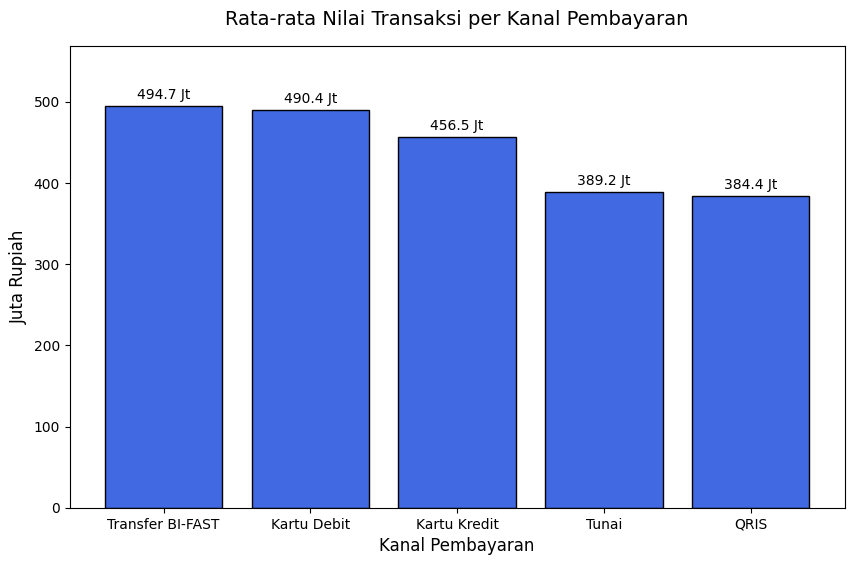

In [ ]:
import matplotlib.pyplot as plt

# Langkah 1: Hitung rata-rata Nilai_Transaksi untuk tiap Kanal_Pembayaran
rata_per_kanal = df_transaksi.groupby('Kanal_Pembayaran')['Nilai_Transaksi'].mean()

# Langkah 2: Urutkan rata-rata dari nilai terbesar ke terkecil
rata_per_kanal = rata_per_kanal.sort_values(ascending=False)

# Langkah 3: Ubah nilai rata-rata ke satuan Juta Rupiah (dibagi 1.000.000)
rata_per_kanal_juta = rata_per_kanal / 1000000

# Langkah 4: Buat figur grafik baru
plt.figure(figsize=(10, 6))

# Langkah 5: Gambar diagram batang vertikal
batang = plt.bar(rata_per_kanal_juta.index, rata_per_kanal_juta.values, color='royalblue', edgecolor='black')

# Langkah 6: Tambahkan judul grafik dan label sumbu
plt.title('Rata-rata Nilai Transaksi per Kanal Pembayaran', fontsize=14, pad=15)
plt.ylabel('Juta Rupiah', fontsize=12)
plt.xlabel('Kanal Pembayaran', fontsize=12)

# Langkah 7: Tampilkan angka nilai di atas setiap batang
for b in batang:
    tinggi_batang = b.get_height()
    plt.text(
        b.get_x() + b.get_width()/2.0,
        tinggi_batang + 5, # posisi teks sedikit di atas ujung batang
        f'{tinggi_batang:.1f} Jt',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Memperluas batas sumbu Y ke atas sedikit agar teks angka tidak terpotong
plt.ylim(0, rata_per_kanal_juta.max() * 1.15)

# Langkah 8: Simpan hasil grafik menjadi file gambar PNG
plt.savefig('grafik_1_kanal.png', dpi=150, bbox_inches='tight')

# Langkah 9: Tampilkan grafik di layar
plt.show()

Sheet 2

                             Usia  Frekuensi_Gunakan_QRIS  Kepuasan_Layanan_QRIS  Persepsi_Keamanan_Transaksi  Pengetahuan_BI_FAST  Niat_Menggunakan_Lagi  Loyalitas
Usia                         1.00                    0.07                   0.05                        -0.15                -0.11                   0.12       0.03
Frekuensi_Gunakan_QRIS       0.07                    1.00                  -0.09                         0.02                 0.04                  -0.07       0.02
Kepuasan_Layanan_QRIS        0.05                   -0.09                   1.00                         0.01                 0.09                   0.13      -0.09
Persepsi_Keamanan_Transaksi -0.15                    0.02                   0.01                         1.00                 0.03                   0.05       0.22
Pengetahuan_BI_FAST         -0.11                    0.04                   0.09                         0.03                 1.00                  -0.11      -0.08
Niat_Mengg

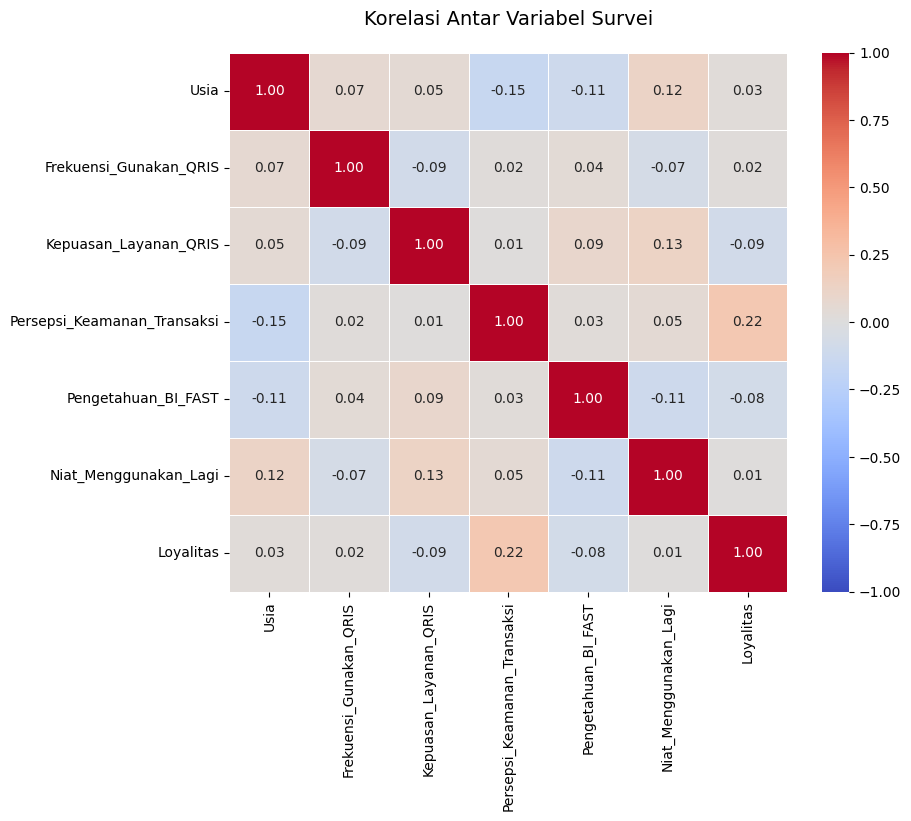

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Langkah 1: Ambil hanya 7 kolom angka yang ingin dianalisis
kolom_pilihan_survei = df_survei[[
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]]

# Langkah 2: Hitung matriks korelasi Pearson dan bulatkan hasilnya
korelasi_survei = kolom_pilihan_survei.corr().round(2)

# Langkah 3: Tampilkan tabel korelasi secara utuh di layar
print(korelasi_survei.to_string())

# Langkah 4: Tentukan ukuran gambar heatmap (9 x 7 inci)
plt.figure(figsize=(9, 7))

# Langkah 5: Buat visualisasi heatmap dengan seaborn
sns.heatmap(
    korelasi_survei,
    annot=True,            # Tampilkan nilai angka di dalam kotak
    fmt=".2f",             # Format desimal angka di dalam kotak
    cmap='coolwarm',       # Skema warna dari biru (negatif) ke merah (positif)
    vmin=-1,               # Nilai batas minimum skala korelasi
    vmax=1,                # Nilai batas maksimum skala korelasi
    linewidths=0.5         # Jarak garis tipis antar kotak
)

# Langkah 6: Tambahkan judul grafik
plt.title('Korelasi Antar Variabel Survei', fontsize=14, pad=20)

# Langkah 7: Simpan hasil grafik menjadi file gambar PNG
plt.savefig('grafik_3_korelasi.png', dpi=150, bbox_inches='tight')

# Langkah 8: Tampilkan grafik di layar
plt.show()

Sheet 3

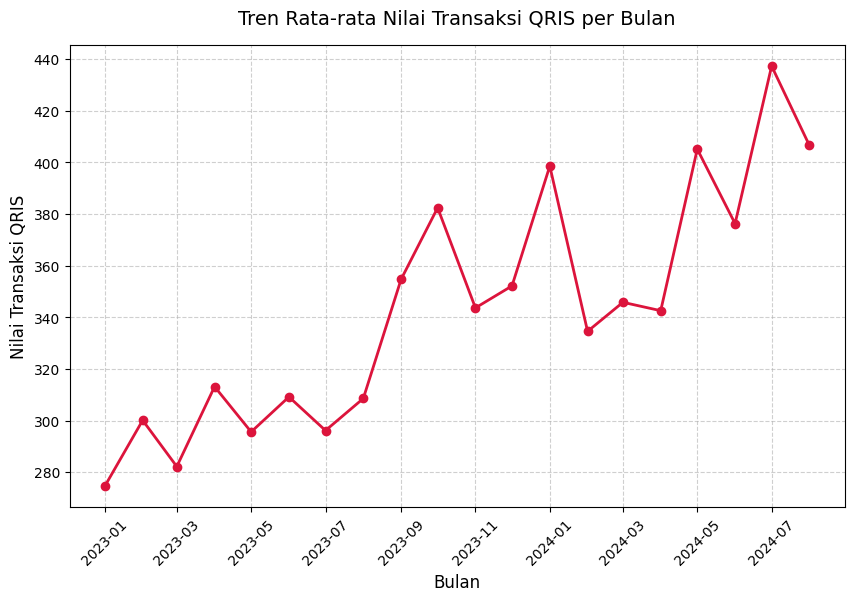

In [ ]:
import matplotlib.pyplot as plt

# Langkah 1: Hitung rata-rata Nilai_Transaksi_QRIS untuk tiap Bulan (semua provinsi digabung)
rata_per_bulan = df_makro.groupby('Bulan')['Nilai_Transaksi_QRIS'].mean()

# Langkah 2: Urutkan data berdasarkan urutan bulan dari yang paling awal ke paling akhir
rata_per_bulan = rata_per_bulan.sort_index()

# Langkah 3: Tentukan ukuran gambar grafik (10 x 6 inci)
plt.figure(figsize=(10, 6))

# Langkah 4: Buat diagram garis dengan titik penanda (marker 'o') di tiap bulannya
plt.plot(rata_per_bulan.index, rata_per_bulan.values, marker='o', color='crimson', linewidth=2, label='Rata-rata QRIS')

# Langkah 5: Tambahkan judul grafik, label sumbu X, dan label sumbu Y
plt.title('Tren Rata-rata Nilai Transaksi QRIS per Bulan', fontsize=14, pad=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Nilai Transaksi QRIS', fontsize=12)

# Langkah 6: Putar tulisan tanggal di sumbu X sebesar 45 derajat agar rapi dan tidak bertabrakan
plt.xticks(rotation=45)

# Langkah 7: Tambahkan garis bantu (grid) agar grafik lebih mudah dibaca
plt.grid(True, linestyle='--', alpha=0.6)

# Langkah 8: Simpan hasil grafik menjadi file gambar PNG
plt.savefig('grafik_2_tren.png', dpi=150, bbox_inches='tight')

# Langkah 9: Tampilkan grafik di layar
plt.show()

## Regresi Sederhana - Sheet Makro

Koefisien Regresi: 0.6355
Intercept: 5.5010
R-squared (R2): 0.9404
Nilai Korelasi: 0.9698


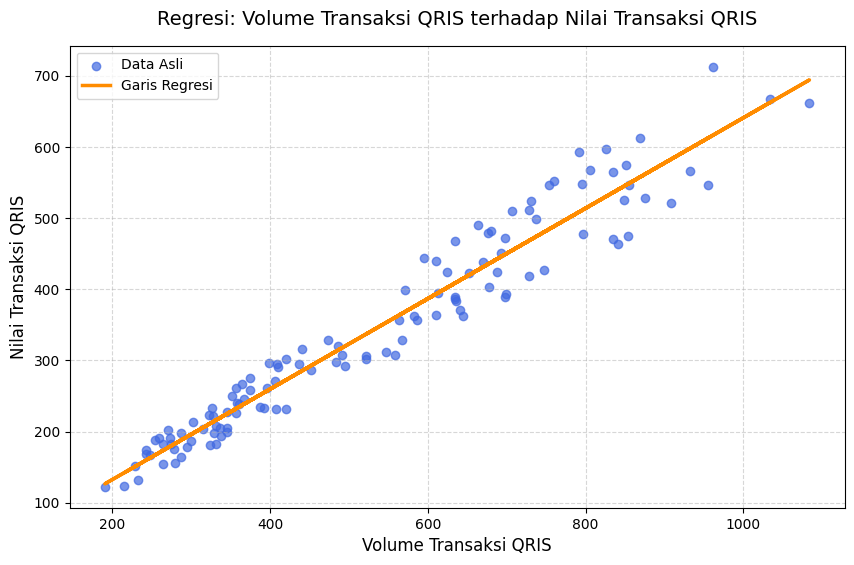

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Langkah 1: Siapkan variabel X (dua dimensi) dan y
X = df_makro[['Volume_Transaksi_QRIS']]
y = df_makro['Nilai_Transaksi_QRIS']

# Langkah 2: Buat model regresi linear dan latih dengan seluruh data
model = LinearRegression()
model.fit(X, y)

# Langkah 3: Ambil nilai koefisien, intercept, dan R-squared
koefisien_regresi = model.coef_[0]
intercept_regresi = model.intercept_
r_kuadrat = model.score(X, y)

# Langkah 4: Hitung nilai korelasi Pearson antara kedua kolom
korelasi_volume_nilai = df_makro['Volume_Transaksi_QRIS'].corr(df_makro['Nilai_Transaksi_QRIS'])

# Langkah 5: Tampilkan hasil perhitungan dengan pembulatan 4 desimal
print(f"Koefisien Regresi: {koefisien_regresi:.4f}")
print(f"Intercept: {intercept_regresi:.4f}")
print(f"R-squared (R2): {r_kuadrat:.4f}")
print(f"Nilai Korelasi: {korelasi_volume_nilai:.4f}")

# Langkah 6: Hitung nilai prediksi untuk menggambar garis regresi
y_prediksi = model.predict(X)

# Langkah 7: Buat visualisasi diagram sebar dan garis regresi
plt.figure(figsize=(10, 6))

# Gambar titik data asli
plt.scatter(X, y, color='royalblue', alpha=0.7, label='Data Asli')

# Gambar garis regresi
plt.plot(X, y_prediksi, color='darkorange', linewidth=2.5, label='Garis Regresi')

# Langkah 8: Atur judul, label sumbu, dan legenda
plt.title('Regresi: Volume Transaksi QRIS terhadap Nilai Transaksi QRIS', fontsize=14, pad=15)
plt.xlabel('Volume Transaksi QRIS', fontsize=12)
plt.ylabel('Nilai Transaksi QRIS', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Langkah 9: Simpan gambar grafik
plt.savefig('grafik_4_regresi.png', dpi=150, bbox_inches='tight')

# Langkah 10: Tampilkan grafik di layar
plt.show()

## BUAT REPORT DI MSWORD

5a. Kerangka + tabel + gambar visualisasi

In [ ]:
# 1. Install library python-docx secara diam-diam
!pip install -q python-docx

import os
import pandas as pd
from docx import Document
from docx.shared import Inches, Pt
from google.colab import files

# Fungsi pembantu untuk memformat angka dengan gaya Indonesia (titik ribuan, koma desimal)
def format_id(nilai, desimal=2):
    if pd.isna(nilai):
        return "-"
    # Bulatkan nilai terlebih dahulu
    nilai_bulat = round(nilai, desimal)
    if desimal == 0:
        format_str = "{:,}".format(int(nilai_bulat))
    else:
        format_str = "{:,}".format(nilai_bulat)

    # Ganti pemisah ribuan koma (default US) menjadi titik, dan desimal titik menjadi koma
    # Gunakan placeholder sementara
    placeholder_ribuan = "[RIBUAN]"
    placeholder_desimal = "[DESIMAL]"

    hasil = format_str.replace(",", placeholder_ribuan).replace(".", placeholder_desimal)
    hasil = hasil.replace(placeholder_ribuan, ".").replace(placeholder_desimal, ",")
    return hasil

# 2. Inisialisasi dokumen baru
doc = Document()

# Tambahkan judul utama laporan
judul = doc.add_heading(level=0)
run_judul = judul.add_run("Laporan Analisis Data Latihan Bank Indonesia")
run_judul.font.name = 'Arial'
run_judul.font.size = Pt(20)

# --- BAGIAN A: STATISTIK DESKRIPTIF ---
doc.add_heading("A. Statistik Deskriptif", level=1)

# Daftar tabel yang akan dimasukkan ke dokumen
tabel_list = [
    {
        "judul": "A.1 Data Transaksi",
        "df": ringkasan_transaksi,
        "desimal": 0
    },
    {
        "judul": "A.2 Data Survei Persepsi",
        "df": ringkasan_survei,
        "desimal": 2
    },
    {
        "judul": "A.3 Data Makro Inklusi Keuangan",
        "df": ringkasan_makro,
        "desimal": 2
    }
]

# Membuat masing-masing tabel secara berurutan
for t_info in tabel_list:
    doc.add_heading(t_info["judul"], level=2)
    df_temp = t_info["df"]
    desimal_temp = t_info["desimal"]

    # Ambil list nama kolom dan indeks statistik
    nama_kolom = list(df_temp.columns)
    indeks_baris = list(df_temp.index)  # count, mean, std, dll.

    # Jumlah baris tabel = 1 (header) + jumlah indeks (8)
    # Jumlah kolom tabel = 1 (kolom Statistik) + jumlah kolom data
    jumlah_baris_tabel = len(indeks_baris) + 1
    jumlah_kolom_tabel = len(nama_kolom) + 1

    # Tambahkan tabel dengan gaya 'Table Grid'
    tabel = doc.add_table(rows=jumlah_baris_tabel, cols=jumlah_kolom_tabel)
    tabel.style = 'Table Grid'

    # Isi header tabel (baris pertama)
    tabel.cell(0, 0).text = "Statistik"
    for col_idx, col_name in enumerate(nama_kolom):
        tabel.cell(0, col_idx + 1).text = str(col_name)

    # Isi data tabel dari DataFrame
    for r_idx, stat_name in enumerate(indeks_baris):
        # Kolom pertama berisi nama statistik
        tabel.cell(r_idx + 1, 0).text = str(stat_name)

        # Kolom berikutnya diisi angka yang diformat
        for c_idx, col_name in enumerate(nama_kolom):
            nilai_asli = df_temp.loc[stat_name, col_name]
            nilai_format = format_id(nilai_asli, desimal=desimal_temp)
            tabel.cell(r_idx + 1, c_idx + 1).text = nilai_format

    # Atur semua ukuran font sel tabel menjadi 8 pt
    for baris in tabel.rows:
        for sel in baris.cells:
            for paragraf in sel.paragraphs:
                for run in paragraf.runs:
                    run.font.size = Pt(8)
                    run.font.name = 'Arial'

    # Beri satu baris kosong setelah tabel
    doc.add_paragraph()

# --- BAGIAN B: VISUALISASI ---
doc.add_heading("B. Visualisasi", level=1)

# Daftar gambar yang akan dimasukkan ke dokumen
gambar_list = [
    {
        "file": "grafik_1_kanal.png",
        "keterangan": "Gambar 1. Rata-rata nilai transaksi per kanal pembayaran."
    },
    {
        "file": "grafik_2_tren.png",
        "keterangan": "Gambar 2. Tren rata-rata nilai transaksi QRIS per bulan."
    },
    {
        "file": "grafik_3_korelasi.png",
        "keterangan": "Gambar 3. Korelasi antar variabel survei."
    },
    {
        "file": "grafik_4_regresi.png",
        "keterangan": "Gambar 4. Regresi volume transaksi QRIS terhadap nilai transaksi QRIS."
    }
]

# Memasukkan gambar satu per satu secara rapi
for g_info in gambar_list:
    file_path = g_info["file"]
    if os.path.exists(file_path):
        # Tambahkan gambar dengan lebar 5.5 inci
        doc.add_picture(file_path, width=Inches(5.5))

        # Tambahkan keterangan gambar tepat di bawahnya
        par_ket = doc.add_paragraph(g_info["keterangan"])
        run_ket = par_ket.runs[0] if par_ket.runs else par_ket.add_run()
        run_ket.font.size = Pt(10)
        run_ket.font.italic = True
        run_ket.font.name = 'Arial'

        # Beri satu baris kosong setelah gambar dan keterangan
        doc.add_paragraph()
    else:
        print(f"Peringatan: File gambar {file_path} tidak ditemukan.")

# 3. Simpan dokumen Word
nama_laporan = "laporan_analisis_bi.docx"
doc.save(nama_laporan)
print(f"Laporan berhasil dibuat dan disimpan dengan nama: {nama_laporan}")

# 4. Unduh otomatis file laporan ke komputer
files.download(nama_laporan)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.7 MB/s eta 0:00:00
Laporan berhasil dibuat dan disimpan dengan nama: laporan_analisis_bi.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5b. Tambah penjelasan ke dalam laporan

In [ ]:
import os
import pandas as pd
from docx import Document
from docx.shared import Inches, Pt
from google.colab import files

# Fungsi pembantu untuk memformat angka dengan gaya Indonesia (titik ribuan, koma desimal)
def format_id(nilai, desimal=2):
    if pd.isna(nilai):
        return "-"
    nilai_bulat = round(nilai, desimal)
    if desimal == 0:
        format_str = "{:,}".format(int(nilai_bulat))
    else:
        format_str = "{:,}".format(nilai_bulat)

    placeholder_ribuan = "[RIBUAN]"
    placeholder_desimal = "[DESIMAL]"

    hasil = format_str.replace(",", placeholder_ribuan).replace(".", placeholder_desimal)
    hasil = hasil.replace(placeholder_ribuan, ".").replace(placeholder_desimal, ",")
    return hasil

# 1. Inisialisasi dokumen baru
doc = Document()

# Tambahkan judul utama laporan
judul = doc.add_heading(level=0)
run_judul = judul.add_run("Laporan Analisis Data Latihan Bank Indonesia")
run_judul.font.name = 'Arial'
run_judul.font.size = Pt(20)

# --- BAGIAN PENDAHULUAN ---
pendahuluan_teks = "Laporan ini merangkum hasil analisis tiga kumpulan data latihan yang telah dibersihkan: data transaksi (194 baris, periode Januari sampai Desember 2024), data survei persepsi responden (146 baris), dan data makro inklusi keuangan di enam provinsi (120 baris, periode Januari 2023 sampai Agustus 2024). Analisis mencakup statistik deskriptif, visualisasi, korelasi, dan regresi linear sederhana."
doc.add_heading("Pendahuluan", level=1)
doc.add_paragraph(pendahuluan_teks)

# --- BAGIAN A: STATISTIK DESKRIPTIF ---
doc.add_heading("A. Statistik Deskriptif", level=1)

# Daftar tabel yang akan dimasukkan ke dokumen
tabel_list = [
    {
        "judul": "A.1 Data Transaksi",
        "df": ringkasan_transaksi,
        "desimal": 0
    },
    {
        "judul": "A.2 Data Survei Persepsi",
        "df": ringkasan_survei,
        "desimal": 2
    },
    {
        "judul": "A.3 Data Makro Inklusi Keuangan",
        "df": ringkasan_makro,
        "desimal": 2
    }
]

# Membuat masing-masing tabel secara berurutan
for t_info in tabel_list:
    doc.add_heading(t_info["judul"], level=2)
    df_temp = t_info["df"]
    desimal_temp = t_info["desimal"]

    nama_kolom = list(df_temp.columns)
    indeks_baris = list(df_temp.index)

    jumlah_baris_tabel = len(indeks_baris) + 1
    jumlah_kolom_tabel = len(nama_kolom) + 1

    tabel = doc.add_table(rows=jumlah_baris_tabel, cols=jumlah_kolom_tabel)
    tabel.style = 'Table Grid'

    tabel.cell(0, 0).text = "Statistik"
    for col_idx, col_name in enumerate(nama_kolom):
        tabel.cell(0, col_idx + 1).text = str(col_name)

    for r_idx, stat_name in enumerate(indeks_baris):
        tabel.cell(r_idx + 1, 0).text = str(stat_name)
        for c_idx, col_name in enumerate(nama_kolom):
            nilai_asli = df_temp.loc[stat_name, col_name]
            nilai_format = format_id(nilai_asli, desimal=desimal_temp)
            tabel.cell(r_idx + 1, c_idx + 1).text = nilai_format

    for baris in tabel.rows:
        for sel in baris.cells:
            for paragraf in sel.paragraphs:
                for run in paragraf.runs:
                    run.font.size = Pt(8)
                    run.font.name = 'Arial'

    doc.add_paragraph()

# --- BAGIAN B: VISUALISASI ---
doc.add_heading("B. Visualisasi", level=1)

gambar_list = [
    {
        "file": "grafik_1_kanal.png",
        "keterangan": "Gambar 1. Rata-rata nilai transaksi per kanal pembayaran."
    },
    {
        "file": "grafik_2_tren.png",
        "keterangan": "Gambar 2. Tren rata-rata nilai transaksi QRIS per bulan."
    },
    {
        "file": "grafik_3_korelasi.png",
        "keterangan": "Gambar 3. Korelasi antar variabel survei."
    },
    {
        "file": "grafik_4_regresi.png",
        "keterangan": "Gambar 4. Regresi volume transaksi QRIS terhadap nilai transaksi QRIS."
    }
]

for g_info in gambar_list:
    file_path = g_info["file"]
    if os.path.exists(file_path):
        doc.add_picture(file_path, width=Inches(5.5))
        par_ket = doc.add_paragraph(g_info["keterangan"])
        run_ket = par_ket.runs[0] if par_ket.runs else par_ket.add_run()
        run_ket.font.size = Pt(10)
        run_ket.font.italic = True
        run_ket.font.name = 'Arial'
        doc.add_paragraph()
    else:
        print(f"Peringatan: File gambar {file_path} tidak ditemukan.")

# --- BAGIAN C: CATATAN DATA ---
doc.add_heading("C. Catatan Data", level=1)

catatan_data_list = [
    "Berkas latihan semula berisi 200 baris data transaksi, 150 baris data survei, and 120 baris data makro. Setelah pembersihan, jumlah baris menjadi 194, 146, and 120.",
    "Aturan pembersihan yang digunakan: tanggal bergaris miring dibaca sebagai hari/bulan/tahun; usia dianggap wajar pada rentang 17 sampai 100 tahun; skala frekuensi penggunaan 1 sampai 7 dan skor survei lainnya 1 sampai 5; nilai negatif dan nilai ekstrem dikosongkan lalu diisi dengan median; sel teks yang kosong diisi dengan modus; data makro yang kosong diisi dengan median per provinsi.",
    "Keputusan pengisian median memengaruhi hasil. Pada kolom Nilai_Transaksi, nilai 419.292.000 muncul 10 kali karena berasal dari pengisian median, sehingga nilai tengah (50%) kolom tersebut sama dengan angka ini. Rata-rata dan sebaran kolom tersebut perlu dibaca dengan kehati-hatian."
]

for paragraf_teks in catatan_data_list:
    doc.add_paragraph(paragraf_teks)

doc.add_paragraph()

# --- BAGIAN D: TEMUAN DAN KESIMPULAN ---
doc.add_heading("D. Temuan dan Kesimpulan", level=1)

temuan_list = [
    {
        "judul": "D.1 Kanal Pembayaran",
        "isi": "Rata-rata nilai transaksi tertinggi terdapat pada kanal Transfer BI-FAST (494,75 juta rupiah), disusul Kartu Debit (490,39 juta) dan Kartu Kredit (456,53 juta). Rata-rata terendah terdapat pada Tunai (389,20 juta) dan QRIS (384,35 juta). Perlu dicatat bahwa QRIS adalah kanal dengan jumlah transaksi terbanyak (67 dari 194 transaksi)."
    },
    {
        "judul": "D.2 Tren Transaksi QRIS",
        "isi": "Rata-rata nilai transaksi QRIS per bulan cenderung naik, dari 274,62 pada Januari 2023 menjadi 406,55 pada Agustus 2024, dengan puncak 437,30 pada Juli 2024. Kenaikan tersebut tidak mulus karena terdapat naik-turun antarbulan."
    },
    {
        "judul": "D.3 Korelasi Variabel Survei",
        "isi": "Rata-rata skor survei berada di sekitar tengah skala, yaitu 2,85 sampai 3,16 pada skala 1 sampai 5 (frekuensi penggunaan QRIS rata-rata 3,96 pada skala 1 sampai 7). Seluruh korelasi antar variabel survei tergolong lemah. Korelasi tertinggi adalah Persepsi Keamanan Transaksi dengan Loyalitas (0,22) dan korelasi terendah adalah Usia dengan Persepsi Keamanan Transaksi (-0,15). Dengan demikian tidak ditemukan hubungan yang kuat antar variabel survei."
    },
    {
        "judul": "D.4 Regresi Data Makro",
        "isi": "Pada data makro, regresi linear sederhana menunjukkan bahwa setiap kenaikan 1 poin Volume Transaksi QRIS diikuti kenaikan sekitar 0,64 poin Nilai Transaksi QRIS (koefisien 0,6355). Nilai R-kuadrat sebesar 0,9404 dan korelasi sebesar 0,9698 menunjukkan hubungan yang sangat kuat. Pada volume besar (di atas sekitar 800), titik data lebih menyebar dari garis sehingga perkiraan pada rentang tersebut kurang presisi. Hubungan ini menunjukkan keterkaitan, bukan bukti sebab-akibat."
    },
    {
        "judul": "D.5 Kesimpulan",
        "isi": "Secera ringkas: (1) nilai transaksi QRIS cenderung naik sepanjang periode pengamatan; (2) volume dan nilai transaksi QRIS berkaitan sangat kuat; (3) variabel survei tidak saling berhubungan secara kuat; (4) hasil pada data transaksi perlu dibaca dengan memperhatikan pengisian median."
    }
]

for temuan in temuan_list:
    doc.add_heading(temuan["judul"], level=2)
    doc.add_paragraph(temuan["isi"])

# Simpan dokumen Word
nama_laporan_lengkap = "laporan_analisis_bi_lengkap.docx"
doc.save(nama_laporan_lengkap)
print(f"Laporan lengkap berhasil dibuat dan disimpan: {nama_laporan_lengkap}")

# Unduh otomatis ke komputer
files.download(nama_laporan_lengkap)

Laporan lengkap berhasil dibuat dan disimpan: laporan_analisis_bi_lengkap.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>